In [1]:
import requests                     # Downloads raw .dat files from GitHub URLs
                                    # [https://docs.python-requests.org/en/latest/]
from io import StringIO             # Converts downloaded string to file-like object for pandas
import pandas as pd                 # Parses, cleans, structures data into DataFrames; enables grouping/splitting
                                    # [https://pandas.pydata.org/docs/]
import numpy as np                   # Numerical arrays, interpolation, stats, error propagation
                                    # [https://numpy.org/doc/]
import re                           # Regex to extract long names and units from column headers (e.g., "Moment (emu)")
from collections import defaultdict  # Organizes metadata key-value pairs during header parsing
import math                         # Basic math functions (sqrt, exp) for calculations

# Visualization
import matplotlib.pyplot as plt     # Generates static plots: M-H loops, M-T curves, parameter trends
                                    # [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html]

import os                           # File system operations for exporting data

# BACKGROUND



## Problem Statement


Understanding how magnetic phases evolve in rare-earth (RE) multilayer thin films is key to
advancing spin-based memory and logic devices. This project analyzes Ho/Er multilayers, where
different Ho layer thicknesses induce temperature-dependent conical and helical magnetic
phases and an exchange-bias shift.

The analysis will use SQUID magnetometry data: samples S16 (Ho₇|Er₂₁) and S17 (Ho₂₉|Er₂₁),
each measured under varying magnetic fields and temperatures. Two datasets (both M–
H–T) record how magnetization changes with temperature.

Existing mean-field and anisotropic Ising-type models describe such RE multilayer behavior, but
their adequacy in accounting for interfacial disorder and spin imbalance remains uncertain.
Evaluating how well these models fit the data and identifying where they fail form the core of
this study.

Manual interpretation of multi-file SQUID data is slow and error-prone, so this project will
develop an automated, auditable workflow in Google Colab that:

(1) Imports and cleans raw ASCII data by parsing headers, units, removing background signals
(paramagnetic or diamagnetic artifacts).

(2) Extracts coercivity, remanence, and exchange-bias (Hₑᵦ) values.  

(3) Visualizes M-H curves to reveal phase
transitions and spin reorientation behavior.

(4) Performs statistical model testing to determine whether mean-field or Ising-type models
adequately explain the observed magnetic behavior. For M–H data: fit effective anisotropy model
K(T) ~ exp(-Δ/T) to extracted parameters (Hc, Mr, Heb) and quantify fit quality via R², residuals,
and propagated uncertainties. **Model adequacy is determined
by**: (i) goodness-of-fit metrics (R² > 0.90, reduced χ² ≈ 1), (ii) hypothesis tests rejecting null
models when p < 0.05 (indicating systematic deviations that reveal interfacial disorder or phase
mismatches), and (iii) cross-validation with OriginLab reprocessing to exclude artifacts. This
approach identifies where models fail and guides refinement toward physically accurate
descriptions of Ho/Er multilayer coupling.

Integrating LLM-assisted automation for outlier detection, parameter extraction, and model
validation, this workflow will streamline quantitative analysis and provide a transparent,
auditable method for studying magnetic coupling in RE multilayers. Through this process, I aim
to strengthen skills in data visualization, error analysis, and parameter extraction.

LLM (ChatGPT) usage in the statement: I used ChatGPT to pull out key points from my manul
data-processing notes and reference paper following the project guidelines, and to help make
the statement clearer and more concise. All data analysis and validation were done by me.

## Prior Work

1. **Huang et al., *J. Magn. Magn. Mater.* **585**, 171108 (2023)**  
   **Content**: Demonstrates exchange bias in Er/Tb multilayers occurring below 20 K, attributed to spin imbalance within the Er conical magnetic phase. The study quantifies irreversible spin populations at the Er/Tb interface.  
   **Relevance**: Provides a foundation for understanding how conical phases in rare-earth multilayers generate exchange bias. The RKKY coupling model and empirical irreversible spin counting method inform parameter extraction strategies for analyzing Ho/Er interface effects in this project.

2. **Xiao et al., *Phys. Rev. B* **109**, 174422 (2024)**  
   **Content**: Investigates exchange bias in Ho/Tb multilayers, identifying sublattice disorder within the Ho conical phase as the primary mechanism. Uses an n-vector mean-field Hamiltonian to model temperature-dependent bias and validates with Curie-Weiss fits to susceptibility data.  
   **Relevance**: Directly applicable to Ho/Er systems studied here. The mean-field modeling approach and Curie-Weiss analysis provide templates for hypothesis testing in step (4) of the workflow. The focus on Ho layer thickness dependence guides comparison between S16 and S17 samples.

3. **Xiao et al., *Appl. Phys. Lett.* **124**, 142401 (2024)**  
   **Content**: Reports spin-flop transitions in Er/Ho thin films using field-dependent magnetometry. Develops a phenomenological free-energy model (Eq. 1 in that paper) incorporating both uniaxial and basal-plane anisotropy to explain field-induced phase changes.  
   **Relevance**: The free-energy framework is essential for interpreting M–H loop shapes and field-induced transitions observed in this project's data. Anisotropy parameters extracted from fits can be compared to predicted values from this model to assess adequacy.

4. **Huang et al., *Sci. Rep.* **12**, 21836 (2022)**  
   **Content**: Explores indirect magnetic coupling in Mn₃Ir/CoFe/Dy trilayers through helicity inversion of the antiferromagnetic order. Models coupling via antiferromagnetic sublattice imbalance propagated through RKKY interactions across spacer layers.  
   **Relevance**: While focusing on different materials, the RKKY propagation mechanism and sublattice imbalance framework are conceptually transferable to Ho/Er interfaces. Demonstrates how interfacial disorder can couple through non-magnetic spacers, informing interpretation of long-range coupling effects.

5. **Xiao et al., *Phys. Rev. B* **109**, 224403 (2024)**  
   **Content**: **Primary benchmark for this project.** Reports exchange bias in Ho/Er multilayers arising from conical-phase disorder, using the exact samples (S16, S17) analyzed here. Presents spin-imbalance model (Eq. 1) relating bias field to irreversible spin density, and validates via remanence peak analysis and temperature-dependent M–H measurements.  
   **Relevance**: This is the reference paper whose results will be reproduced and validated. The automated workflow developed here aims to replicate their parameter extraction (Hc, Mr, Heb) and model fits, while improving reproducibility and enabling hypothesis testing through statistical rigor. Comparison with their published values provides validation of the analysis pipeline.

## Approach to Analysis

**1. Data Import and File Parsing**

Download raw measurement files from the GitHub repository. These files contain both experimental metadata (sample information, measurement conditions) and numerical data. The workflow automatically separates and organizes this information into structured data tables for analysis.

**2. Analyzing Field-Dependent Data (M–H Hysteresis Loops)**

Examine how magnetization responds as the magnetic field sweeps back and forth at various temperatures. The workflow groups measurements by temperature, removes unwanted background signals from the sample holder, extracts key magnetic properties (coercivity, remanence, exchange bias, saturation), and generates multi-panel visualizations showing how magnetic behavior evolves with temperature.

**3. Fitting Physical Models and Testing Hypotheses**

Test whether theoretical physics models accurately describe the experimental observations. For field-dependent data, the workflow fits temperature-dependent anisotropy models and compares exchange bias trends against mean-field predictions. Statistical tests identify where models fail, revealing interfacial disorder or phase mismatches.

**4. Validation and Output**

Export cleaned data, publication-ready figures, and parameter tables. Cross-validate selected results against manual commercial software analysis to verify the automated pipeline produces correct results.

**Overall Goal**: Create a transparent, automated analysis pipeline that reproduces published results while enabling rigorous statistical evaluation of physical models.

# LOAD LIBRARIES

## Library Comments

- **`requests`**  
  Downloads raw `.dat` files directly from GitHub URLs.  
  [Documentation](https://docs.python-requests.org/en/latest/)

- **`io.StringIO`**  
  Converts downloaded string content into a file-like object for in-memory parsing with `pandas`.

- **`pandas`**  
  Parses, cleans, and structures data into DataFrames; enables grouping, splitting, and metadata storage.  
  [Documentation](https://pandas.pydata.org/docs/)

- **`numpy`**  
  Handles numerical arrays, supports interpolation, statistical analysis, and error propagation.  
  [Documentation](https://numpy.org/doc/)

- **`matplotlib.pyplot`**  
  Generates all static plots: M–H loops, M–T curves, and parameter trends.  
  [Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html)

- **`collections.defaultdict`**  
  Organizes metadata key-value pairs during header parsing.

- **`re`**  
  Uses regex to extract long names and units from column headers (e.g., `"Moment (emu)"`).

- **`math`**  
  Provides basic math functions (e.g., `sqrt`, `exp`) for calculations.

- **`scipy`**  
  Performs linear/nonlinear fitting, peak detection, interpolation, and statistical tests (χ², t-test).  
  [Documentation](https://scipy.org/)

## Code Block

In [2]:
import requests                     # Downloads raw .dat files from GitHub URLs
                                    # [https://docs.python-requests.org/en/latest/]
from io import StringIO             # Converts downloaded string to file-like object for pandas
import pandas as pd                 # Parses, cleans, structures data into DataFrames; enables grouping/splitting
                                    # [https://pandas.pydata.org/docs/]
import numpy as np                   # Numerical arrays, interpolation, stats, error propagation
                                    # [https://numpy.org/doc/]
import re                           # Regex to extract long names and units from column headers (e.g., "Moment (emu)")
from collections import defaultdict  # Organizes metadata key-value pairs during header parsing
import math                         # Basic math functions (sqrt, exp) for calculations

# Visualization
import matplotlib.pyplot as plt     # Generates static plots: M-H loops, M-T curves, parameter trends
                                    # [https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html]

import os                           # File system operations for exporting data

In [3]:
# Define function to visualize M-H loops by temperature sets

def plot_mh_sets(groups, y_col, title):
    n = len(groups)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True)
    axes = axes.flatten()
    for ax, (label, frame) in zip(axes, groups.items()):
        ax.plot(frame[x_column], frame[y_col], marker='o', markersize=2, linewidth=0.8)
        ax.set_title(label)
        ax.set_xlabel('Magnetic Field (Oe)')
        ax.set_ylabel(y_col)
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    plt.show()

# IMPORT DATA

Data are imported in this section from GitHub (to enable evaluation by the instructor and class members).

**Class assignments** related to the building of this section include:
*   Data file formatting
*   Loading data

### Raw Data Sources
- **SQUID MPMS3 `.dat` files** (M–H and M–T measurements):  
  Hosted on GitHub:  
  [https://github.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor](https://github.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor)  
  Files used:  
  - `S16-M-H_T.dat`, `S16-M-T_H.dat`  
  - `S17-M-H_T.dat`, `S17-M-T_H.dat`

## Data Import Code

In [4]:
# Download raw data file from GitHub
github_url = 'https://raw.githubusercontent.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor/refs/heads/main/S16-M-H_T.dat'

response = requests.get(github_url)
response.raise_for_status()  # Raise an exception for bad status codes

# Read the raw file sections from the downloaded content
raw_lines = response.text.splitlines()

header_idx = raw_lines.index('[Header]') + 1
data_idx = raw_lines.index('[Data]')
header_lines = raw_lines[header_idx:data_idx]
data_lines = raw_lines[data_idx + 1:]

print(f'Total header rows: {len(header_lines)}')
print(f'Total data rows: {len(data_lines)}')
print('Sample header entries:')
for line in header_lines[:6]:
    print('  ' + line)

Total header rows: 38
Total data rows: 5591
Sample header entries:
  ; MPMS3 Data File (default extension .dat)
  ; Copyright (c) 2007, Quantum Design, Inc. All rights reserved.
  TITLE,
  FILEOPENTIME,3884591358.92161,02/03/2023,1:09 pm
  BYAPP,MPMS3 w/ AC,1.0,1.1
  INFO,MPMS3 Measurement Release 1.1.16 Build 424, MultiVu Release 2.3.4.19,APPNAME


In [5]:
# Parse metadata entries from header

def parse_header_line(line: str):
    if not line or line.startswith(';'):
        return None
    tokens = [segment.strip() for segment in line.split(',')]
    prefix = tokens[0]
    if prefix == 'INFO' and len(tokens) >= 2:
        key = tokens[-1]
        value_tokens = tokens[1:-1]
    else:
        key = prefix
        value_tokens = tokens[1:]
    raw_values = [value for value in value_tokens]
    cleaned = [value for value in value_tokens if value]
    parsed_value = None
    if cleaned:
        parsed_value = cleaned[0] if len(cleaned) == 1 else cleaned
    return key, raw_values, parsed_value

metadata_rows = []
metadata_map = defaultdict(list)

for line in header_lines:
    parsed = parse_header_line(line)
    if not parsed:
        continue
    key, raw_values, parsed_value = parsed
    metadata_rows.append({'Key': key, 'Raw Values': raw_values, 'Parsed Value': parsed_value})
    metadata_map[key].append(parsed_value)

metadata_df = pd.DataFrame(metadata_rows)
metadata = {
    key: values[0] if len(values) == 1 else values
    for key, values in metadata_map.items()
}

In [6]:
# Summarize and display key metadata

print('=== Key Metadata ===')
metadata_display = {
    'Device': 'superconducting quantum interference device (SQUID) magnetometer from Quantum Design (MPMS3)',
    'Sample material': metadata.get('SAMPLE_MATERIAL'),
    'Sample holder': metadata.get('SAMPLE_HOLDER'),
    'Sample offset (mm)': metadata.get('SAMPLE_OFFSET'),
}

for key, value in metadata_display.items():
    print(f'{key}: {value}')

=== Key Metadata ===
Device: superconducting quantum interference device (SQUID) magnetometer from Quantum Design (MPMS3)
Sample material: Nb-Y-[Ho8-Er6]_10-TaN
Sample holder: Quartz
Sample offset (mm): 67


In [7]:
# Build the M-H data frame and extract column information

data_df = pd.read_csv(StringIO('\n'.join(data_lines)))
mh_columns = ['Temperature (K)', 'Magnetic Field (Oe)', 'Moment (emu)']
if 'M. Std. Err. (emu)' in data_df.columns:
    mh_columns.append('M. Std. Err. (emu)')

mh_df = data_df[mh_columns].copy()

print('=== Data Columns ===')
print(f'Chosen columns: {", ".join(mh_columns)}')
print(f'First 3 rows of data:')
display(mh_df.head(3))

=== Data Columns ===
Chosen columns: Temperature (K), Magnetic Field (Oe), Moment (emu), M. Std. Err. (emu)
First 3 rows of data:


,Temperature (K),Magnetic Field (Oe),Moment (emu),M. Std. Err. (emu)
0,1.999925,70000.359375,0.003740,1.467504e-06
1,1.999831,60000.210938,0.003855,1.819988e-06
2,2.000293,50000.269531,0.003958,8.128455e-07


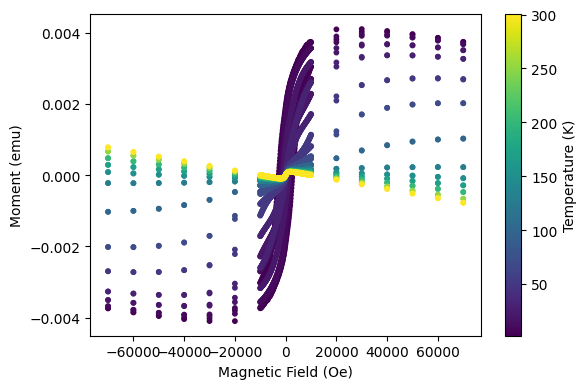

In [8]:
# visualize the M-H curves

fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(
    mh_df['Magnetic Field (Oe)'],
    mh_df['Moment (emu)'],
    c=mh_df['Temperature (K)'],
    s=10,
    cmap='viridis'
)

ax.set_xlabel('Magnetic Field (Oe)')
ax.set_ylabel('Moment (emu)')
cbar = fig.colorbar(scatter, ax=ax, label='Temperature (K)')
plt.tight_layout()
plt.show()

## Description of Approach

# DATA CONDITIONING AND EXPLORATION

In this section, carry out data cleaning and formatting necessary for the **Model Fitting and Hypothesis Testing** section. As approriate, develop hypotheses or test initial hypotheses via plotting and visualization to empirically explore mathematical relationships. Document how you refined your methods, i.e. document what approaches were tried and rejected or accepted and why so that others can learn from what did not work. Note that the sub-sections are iterative. For example, data visualization may lead to the identification of outliers that are then removed from the data.

**Class assignments** related to the building of this section include:

*   Data visualization with background subtraction
*   Analysis plan



## Data Cleaning and Conditioning
Includes formatting, filtering, transforming, etc.

**Goal**: Prepare clean, structured data for accurate parameter extraction and model testing through iterative refinement guided by diagnostic visualizations.

### Header & Metadata Parsing

Extract exactly 36 header lines from the `[Header]` section and parse key-value pairs into a metadata dictionary. Keys extracted include `SAMPLE_MATERIAL`, `SAMPLE_HOLDER`, `SAMPLE_OFFSET`, `SCRIPT_NAME`, etc. Use regex pattern `INFO,<values>,<key>` to handle "INFO" prefix format and standard comma-separated format. Validate that critical fields exist; flag missing required metadata for manual review.

### Column Selection & Unit Parsing

Skip first two columns (`Time Stamp (sec)`, `Temperature Status`) as they contain non-measurement data. Use regex pattern `^(.*?)(?:\s*\((.*)\))?$` to split column labels into long names and units. For example: `"Moment (emu)"` → long name: `"Moment"`, unit: `"emu"`. Store mapping in DataFrame for documentation. Select columns: `Temperature (K)`, `Magnetic Field (Oe)`, `Moment (emu)`, and optionally `M. Std. Err. (emu)` if available.

### Data Type Conversion & Validation

Convert all measurement columns to `float64`. Check for:
- Non-numeric entries (replace or flag for review)
- NaN values (count and report percentage)
- Outliers using z-score > 3 criterion on raw moment values

**Diagnostic Visualization**: Histogram of measurement noise (`M. Std. Err.`) to assess data quality across temperature ranges. If Std. Err. unavailable, estimate from local standard deviation within 10-point windows.

### Temperature Set Splitting (M–H Data)

**Fixed Row Count Method**: Each temperature set contains exactly 430 rows (215 ascending + 215 descending field points). Total rows should divide evenly: `num_sets = len(data) / 430`. Assign `Set ID` (0, 1, 2, ...) and compute mean temperature for each set. Create `Set Label` by rounding mean temperature to nearest integer + "K" (e.g., "5K", "10K").

**Validation Checks**:
- Verify no remainder when dividing total rows by 430
- Confirm temperature standard deviation within each set < 0.5 K
- Check that set temperatures progress monotonically

**Diagnostic Visualization**: Scatter plot of row index vs. temperature showing staircase pattern; overlay vertical lines at set boundaries to confirm proper splitting.

### Background Subtraction (M–H Data)

For each temperature set independently:

**Region Identification**: Sort data by magnetic field. Test both extremes:
- **Left end**: 5 most negative field points (typically -10,000 to -9,500 Oe)
- **Right end**: 5 most positive field points (typically +9,500 to +10,000 Oe)

**Linear Fitting**: For each end, fit `Moment = slope × Field + intercept` using `numpy.polyfit(deg=1)`. Extract fit covariance matrix for uncertainty quantification.

**Validation Criteria**:
1. Slope magnitude: `|slope| < 0.001 emu/Oe` (ensures minimal sample contribution)
2. R² > 0.90 (ensures linearity)
3. Residuals show no systematic trend (visual inspection)

**Adaptive Procedure**:
- If slope out of range, reduce to 2-3 points and refit
- If both ends fail, use fallback: fit to points where `|H| > quantile(0.95)`
- Select the end with more points accepted (prefer stability)

**Background Correction**: 
```
Corrected Moment = Raw Moment - (slope × Field + intercept)
```

**Uncertainty Propagation**: 
```
σ²_corrected = σ²_raw + (σ_slope × Field)² + σ²_intercept
```

**Diagnostic Visualization**: Overlay flagged outliers (red X markers) on corrected M–H loops. Review each flagged point; remove if isolated spike, retain if part of physical feature (e.g., sharp phase transition).

**Documentation**: Record number of outliers per temperature set in metadata; flag sets with >2% outliers for manual inspection.


### Iterative Refinement Workflow

**Iteration 1**: Apply initial background correction with 5-point fits at both ends.

**Visual Check**: Generate before/after M–H comparison grid. Look for:
- Loops centered at origin? → If shifted, background fit failed
- Symmetric coercivity? → If asymmetric, one branch has poor correction
- Smooth curves? → If jagged, outliers present

**Iteration 2**: Based on visual feedback:
- Refit backgrounds using adaptive point reduction for problematic temperatures
- Remove identified outliers
- Regenerate corrected loops

**Visual Check**: Residual plots for high-field regions. Random scatter → proceed. Systematic trend → return to Iteration 2 with stricter slope criteria.

**Iteration 3**: Compare corrected loops across temperatures. Physical expectation: coercivity should decrease with increasing temperature. If non-monotonic, investigate whether specific temperature sets have data quality issues.

**Final Validation**: Plot all corrected loops on single graph color-coded by temperature. Smooth evolution of loop shapes confirms successful conditioning.

### Failed Approaches Documented

**Attempted**: Single global background fit (one slope for all temperatures)  
**Result**: Low-temperature loops overcorrected (negative saturation), high-temperature loops undercorrected (retained slope)  
**Reason**: Background signal is temperature-dependent due to substrate susceptibility changes  
**Lesson**: Per-temperature fitting is essential despite increased computational cost

**Attempted**: Full-loop polynomial fit (subtract fitted polynomial from entire loop)  
**Result**: Hysteresis distorted; coercivity artificially reduced  
**Reason**: Polynomial captures real sample magnetization, not just background  
**Lesson**: Only use high-field linear regions where sample response is minimal

In [9]:
# Choose the magnetic field axis and moment column
x_column = 'Magnetic Field (Oe)'
moment_column = 'Moment (emu)'
print(f'X axis: {x_column}')
print(f'Y axis: {moment_column}')

X axis: Magnetic Field (Oe)
Y axis: Moment (emu)


In [10]:
# Determine rows per temperature set and split data

rows_per_set = 430
num_sets, remainder = divmod(len(data_df), rows_per_set)
if remainder:
    raise ValueError(f'Expected whole number of sets; leftover rows = {remainder}')

set_ids = np.repeat(np.arange(num_sets), rows_per_set)
data_df = data_df.copy()
data_df['Set ID'] = set_ids
data_df['Set Row'] = data_df.groupby('Set ID').cumcount()
set_summary = (
    data_df.groupby('Set ID').agg(
        rows=('Set Row', 'count'),
        temperature_K=('Temperature (K)', 'mean')
    ).reset_index()
)

# Create the 'Set Label' column and merge it into data_df
set_summary['Set Label'] = set_summary['temperature_K'].round().astype(int).astype(str) + 'K'
data_df = data_df.merge(set_summary[['Set ID', 'Set Label']], on='Set ID', how='left')

print(f'Detected {len(set_summary)} temperature sets, {rows_per_set} rows each.')
display(set_summary[['Set ID', 'rows', 'temperature_K', 'Set Label']])

Detected 13 temperature sets, 430 rows each.


,Set ID,rows,temperature_K,Set Label
0,0,430,1.999984,2K
1,1,430,9.999935,10K
2,2,430,19.999870,20K
3,3,430,29.999962,30K
4,4,430,50.000056,50K
5,5,430,70.000125,70K
6,6,430,100.000212,100K
7,7,430,130.000451,130K
8,8,430,150.000453,150K
9,9,430,170.001312,170K


In [11]:
# Add working columns for background correction
data_df['Background Moment (emu)'] = 0.0
data_df['Corrected Moment (emu)'] = data_df[moment_column]

# Group and sort by temperature (extract numeric value from label like "5K" → 5)
temperature_groups = {label: frame.copy().reset_index(drop=True)
                     for label, frame in sorted(data_df.groupby('Set Label'),
                                               key=lambda x: float(x[0].replace('K', '')))}
# print(f'Prepared {len(temperature_groups)} per-temperature data tables.')
# list(temperature_groups.keys())

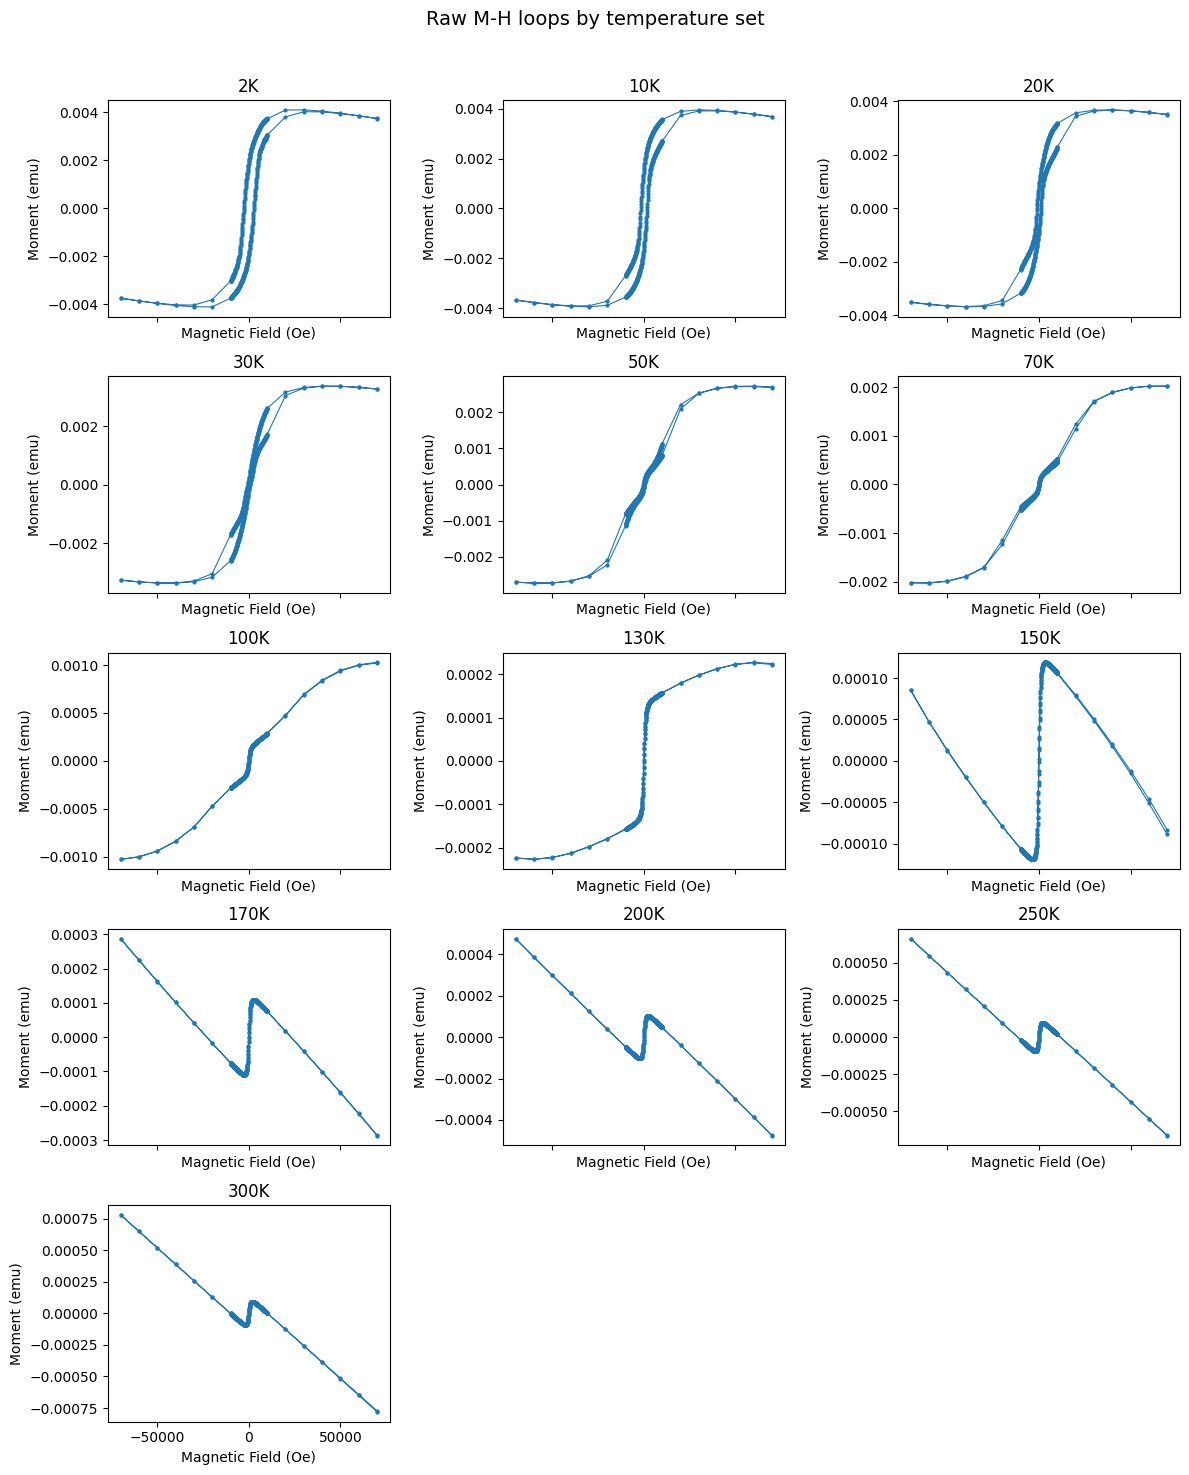

In [12]:
# Visualize raw M-H loops by temperature set
plot_mh_sets(temperature_groups, moment_column, 'Raw M-H loops by temperature set')

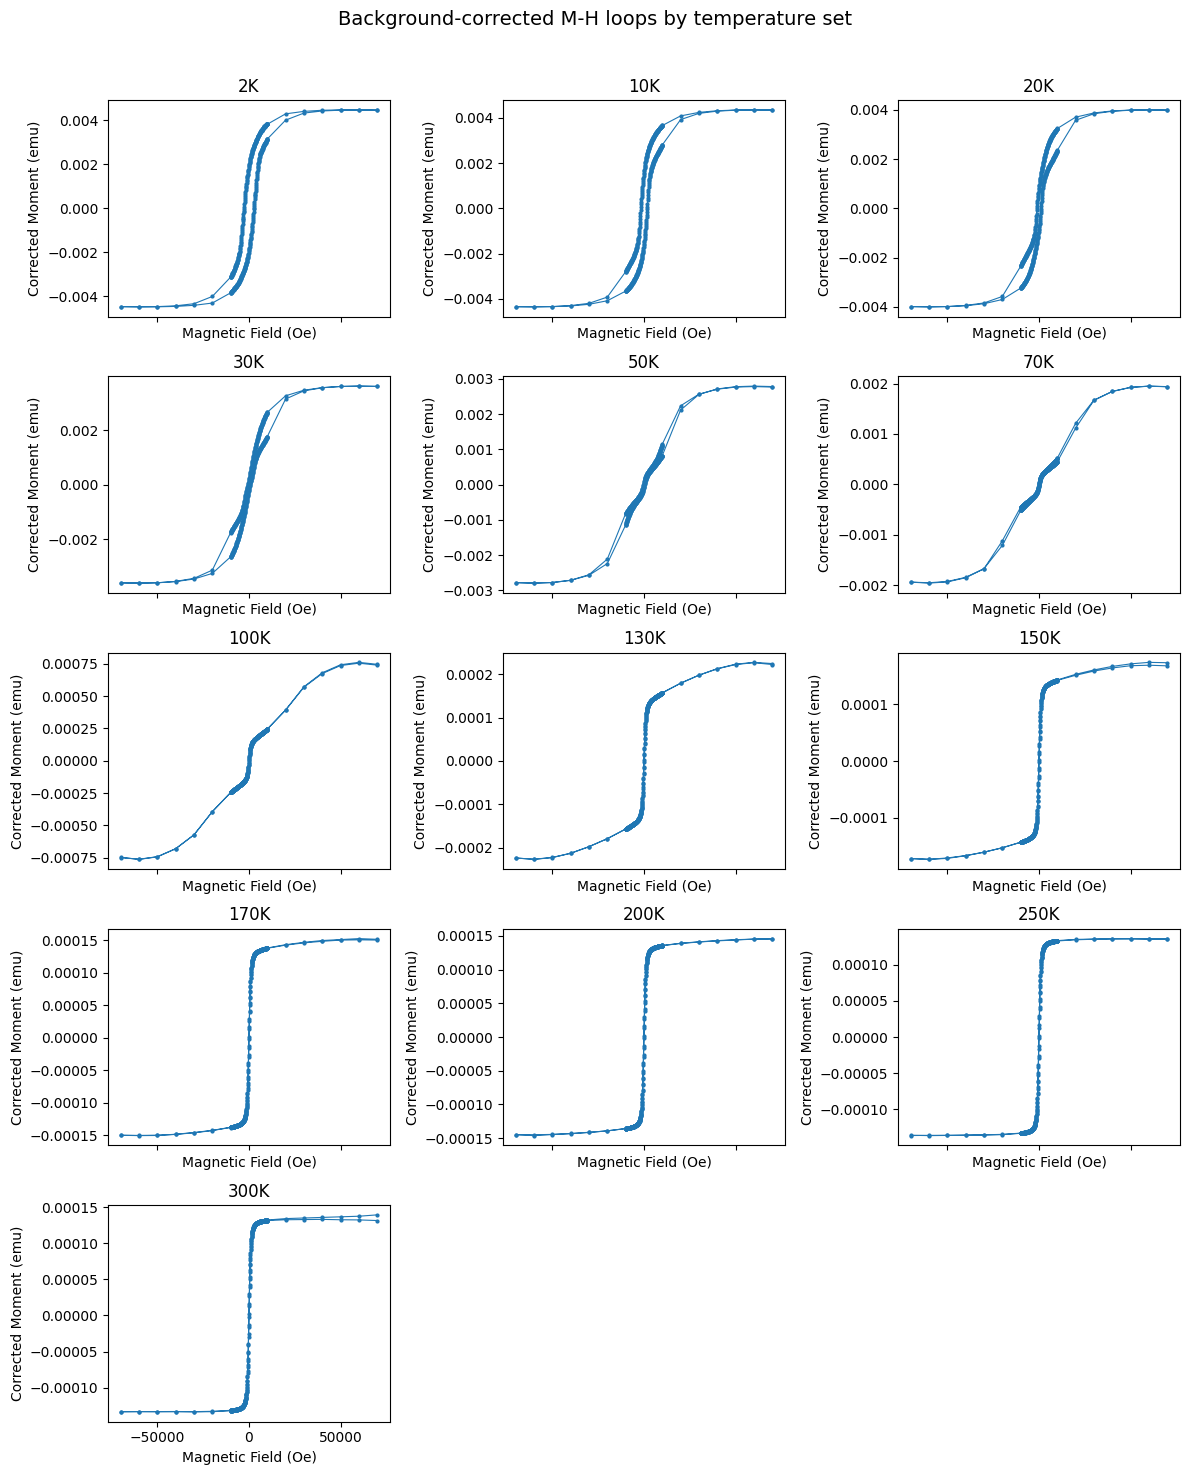

In [13]:
# Linear background correction per temperature set

min_points = 2
max_points = 5
acceptable_slope_range = (-0.001, 0.001)
fit_records = []

for set_id, frame in data_df.groupby('Set ID'):
    label = frame['Set Label'].iat[0]
    temperature = label

    # Sort by magnetic field to locate ends
    sorted_frame = frame.sort_values(x_column)

    # Select the most left and most right points
    left_end = sorted_frame.iloc[:max_points]
    right_end = sorted_frame.iloc[-max_points:]

    best_slope, best_intercept, best_points, best_region = 0.0, 0.0, 0, None

    for end_data, region_name in [(left_end, 'left end'), (right_end, 'right end')]:
        if len(end_data) >= min_points:
            slope, intercept = np.polyfit(end_data[x_column], end_data[moment_column], 1)
            points_used = len(end_data)

            if acceptable_slope_range[0] <= slope <= acceptable_slope_range[1]:
                if points_used > best_points:
                    best_slope, best_intercept, best_points, best_region = slope, intercept, points_used, region_name
            else:
                if points_used > min_points * 2:
                    half_points = max(min_points, points_used // 2)
                    if region_name == 'left end':
                        reduced_data = left_end.iloc[:half_points]
                    else:
                        reduced_data = right_end.iloc[-half_points:]
                    slope_reduced, intercept_reduced = np.polyfit(reduced_data[x_column], reduced_data[moment_column], 1)
                    points_reduced = len(reduced_data)
                    if acceptable_slope_range[0] <= slope_reduced <= acceptable_slope_range[1]:
                        print(f"Set {set_id}, {region_name}: Slope={slope_reduced:.2e}, Points={points_reduced} (Reduced and Accepted)")
                        if points_reduced > best_points:
                            best_slope, best_intercept, best_points, best_region = slope_reduced, intercept_reduced, points_reduced, region_name
                    else:
                        print(f"Set {set_id}, {region_name}: Slope={slope:.2e} out of range, reduction failed")

    # Use the best fit from either end
    if best_points > 0:
        slope, intercept = best_slope, best_intercept
    else:
        quantile_threshold = frame[x_column].abs().quantile(0.95)
        linear_data = frame[frame[x_column].abs() >= quantile_threshold].head(max_points)
        if len(linear_data) >= min_points:
            slope, intercept = np.polyfit(linear_data[x_column], linear_data[moment_column], 1)
            best_points = len(linear_data)
            print(f"Set {set_id}: Fallback High-field, Slope={slope:.2e}, Points={best_points}")
        else:
            slope, intercept = 0.0, 0.0
            best_points = 0
            print(f"Set {set_id}: No valid region found")

    # Apply correction
    frame_index = frame.index
    background_moment = slope * frame[x_column]
    data_df.loc[frame_index, 'Background Moment (emu)'] = background_moment
    data_df.loc[frame_index, 'Corrected Moment (emu)'] = frame[moment_column] - background_moment

    if 'Comments' not in data_df.columns:
        data_df['Comments'] = ''
    data_df.loc[frame_index, 'Comments'] = temperature

    fit_records.append({
        'Set ID': set_id,
        'Set Label': label,
        'Slope (emu/Oe)': slope,
        'Intercept (emu)': intercept,
        'Points used': best_points,
        'Region': best_region if best_points > 0 else 'High-field fallback'
    })

fit_results_df = pd.DataFrame(fit_records)

# Recreate temperature_groups with corrected data, sorted by temperature
temperature_groups = {label: frame.copy().reset_index(drop=True)
                     for label, frame in sorted(data_df.groupby('Set Label'),
                                               key=lambda x: float(x[0].replace('K', '')))}

# Visualize corrected M-H loops by temperature set
plot_mh_sets(temperature_groups, 'Corrected Moment (emu)', 'Background-corrected M-H loops by temperature set')

# PARAMETER ESTIMATION

This section quantitatively compares expectations of a model with trends in the data. It will include measures of goodness of fit including confidence intervals when appropriate. References to the models being considered should be provided in the **BACKGROUND** section. Use sub-sections to show the interative refinement of your approach, i.e. do not simply include the final "best fit", but document at least one analysis approach or model that was considered less optimal.

*   Approaches to Background Fitting (Lecture)

**Goal**: Extract quantitative magnetic properties from cleaned data, test whether physical models accurately describe the measurements, and assess fit quality with proper uncertainty quantification.

### Parameter Estimation from Field-Dependent Data (M–H Loops)

For each temperature, extract the following properties from the corrected hysteresis loops:

- **Coercivity**: The magnetic field strength required to reduce the magnetization to zero after saturation. Found by interpolating where the moment crosses zero on both the ascending and descending branches of the loop, then averaging the absolute values. This tells us how "hard" the magnetic material is—higher values mean the material resists demagnetization more strongly.

- **Remanence**: The magnetization that remains when the applied field is removed (at zero field). Found by interpolating the moment value at zero field and averaging between the two loop branches. This indicates how much magnetic memory the material retains.

- **Exchange Bias**: The horizontal shift of the hysteresis loop away from zero field, indicating asymmetric magnetic coupling at the Ho/Er interface. Calculated as the average of the two zero-crossing field values (one positive, one negative) divided by two. Non-zero values reveal interfacial magnetic coupling between layers.

**Uncertainty Estimation**: Use bootstrap resampling (repeating the extraction 1000 times with random subsets of data) or propagate the reported measurement error plus fitting errors through the interpolation calculations.

# Model Testing

The multilayer thin-film system exhibits three temperature-dependent magnetic phases:

1.  Ho Conical Phase (0–20 K)
2.  Ho Helical Phase (20–131 K)
3.  Er Sinusoidal Phase (52–84 K)

Modeling coercivity (H_c) and remanence (M_r) requires treating each phase separately using physically motivated models. Before fitting, a statistical hypothesis test determines whether ambiguous points belong to the correct phase.


### 1. Hypothesis Testing Before Hc Modeling

#### Objective

Determine whether the 70 K data point should be included in the Ho Helical coercivity fit.

The temperature 70 K lies in an overlap between the Ho Helical and Er Sinusoidal regions. Its correct assignment affects subsequent modeling.

#### Null Hypothesis (H_0)

The 70 K point follows the Helical-phase model:
$$
H_c(T)=A e^{-BT}
$$

#### Alternative Hypothesis (H_1)

The 70 K point does not follow the Helical trend.

#### Method: Extra Sum-of-Squares F-Test

$$
F=\frac{(SSR_{inc}-SSR_{exc})/(N_{inc}-N_{exc})}
{SSR_{exc}/(N_{exc}-p)}
$$

#### Interpretation

*   Reject (H_0):
    → The 70 K point does not belong to the Ho Helical trend.
    → Physically indicates an assignment to the Er Sinusoidal phase.
    → It should be excluded from Helical-phase fitting.

*   Fail to reject (H_0):
    → The point is consistent with the Helical model and included in the fit.


## 2. Modeling Coercivity (H_c(T))

Coercivity reflects anisotropy strength and domain stability. Each magnetic phase is modeled independently using the same functional form.


### 2.1 Ho Conical Phase (0–20 K)

#### Model

$$
H_c(T)=A e^{-BT}
$$

#### Physical Meaning

At low temperature, Ho spins form a conical structure. Strong anisotropy gradually weakens as temperature increases, producing exponential decay behavior.

#### Interpretation of Fitted Parameters

*   (A): intrinsic coercive strength at 0 K
*   (B): thermal decay rate of anisotropy


### 2.2 Ho Helical Phase (20–131 K)

The dataset includes or excludes 70 K depending on the F-test.

#### Model

$$
H_c(T)=A e^{-BT}
$$

#### Physical Meaning

The helical spin structure unwinds with increasing temperature; coercivity decreases as magnetic rigidity weakens.

#### Interpretation of Fitted Parameters

The parameters quantify how rapidly the helical structure loses stability with temperature.


### 2.3 Er Sinusoidal Phase (52–84 K)

#### Model

$$
H_c(T)=A e^{-BT}
$$

#### Physical Meaning

Er spins exhibit sinusoidal modulation, reducing effective anisotropy. The model tests whether this reduction follows a thermally activated process similar to the Ho phases.

#### Fit Interpretation

Comparison with Ho-phase parameters reveals how Er layers alter anisotropy decay.


## 3. Modeling Remanence (M_r(T))

Remanent magnetization reflects the ability of the material to maintain alignment without an external field. Two models are tested independently in each phase:

#### Model A: Linear

$$
M_r(T)=aT+b
$$

#### Model B: Exponential Decay

$$
M_r(T)=A e^{-BT}
$$


### 3.1 Ho Conical Phase (0–20 K)

The exponential model captures the rapid decrease in remanence associated with breakdown of the conical spin structure.


### 3.2 Ho Helical Phase (20–131 K)

Both linear and exponential models are evaluated.

*   Exponential decay corresponds to thermally driven expansion of the helical pitch.
*   A linear model may approximate gradual changes over a broad temperature range.


### 3.3 Er Sinusoidal Phase (52–84 K)

Both models are tested to determine whether Er’s sinusoidal modulation causes simple linear softening or enhanced exponential decay of remanence.


## 4. Combined (M_r) Evaluation Across All Phases

Across the full temperature range:

*   Ho Conical (0–20 K)
*   Ho Helical (20–131 K)
*   Er Sinusoidal (52–84 K)

Both models are plotted together, and the statistically superior model for each region is emphasized.

#### Physical Interpretation

*   Shows how (M_r) evolves across distinct magnetic structures
*   Highlights changes at phase boundaries
*   Identifies which mechanisms dominate thermal degradation of remanence in different phases


## Best Fit/Model/Approach

In [14]:
# Data Preparation for Parameter Extraction

from scipy.interpolate import interp1d

# Recreate temperature_groups from the corrected data_df
temperature_groups = {label: frame.copy().reset_index(drop=True)
                     for label, frame in data_df.groupby('Set Label')}
print(f'Loaded {len(temperature_groups)} corrected temperature datasets for parameter extraction.\n')

Loaded 13 corrected temperature datasets for parameter extraction.



In [15]:
# Helper Functions: Branch Separation and Zero Crossing Detection

def separate_branches(field, moment, moment_err=None):
    """
    Separate M-H loop into ascending and descending branches.
    
    Automatically detects whether the loop starts from max or min field.
    Also separates error arrays if provided.
    """
    # Check if first point is closer to max or min field
    field_max = np.max(field)
    field_min = np.min(field)
    
    if abs(field[0] - field_max) < abs(field[0] - field_min):
        # Data starts from maximum field, find minimum as turning point
        turning_idx = np.argmin(field)
        desc_field = field[:turning_idx+1]
        desc_moment = moment[:turning_idx+1]
        asc_field = field[turning_idx:]
        asc_moment = moment[turning_idx:]
        
        if moment_err is not None:
            desc_err = moment_err[:turning_idx+1]
            asc_err = moment_err[turning_idx:]
        else:
            desc_err = None
            asc_err = None
    else:
        # Data starts from minimum field, find maximum as turning point
        turning_idx = np.argmax(field)
        asc_field = field[:turning_idx+1]
        asc_moment = moment[:turning_idx+1]
        desc_field = field[turning_idx:]
        desc_moment = moment[turning_idx:]
        
        if moment_err is not None:
            asc_err = moment_err[:turning_idx+1]
            desc_err = moment_err[turning_idx:]
        else:
            asc_err = None
            desc_err = None
    
    return asc_field, asc_moment, asc_err, desc_field, desc_moment, desc_err


def find_zero_crossing_with_error(field, moment, moment_err=None, initial_guess=0):
    """
    Find the field value where moment crosses zero using interpolation.
    Also calculates uncertainty using error propagation.
    
    Returns (h_cross, h_cross_err) or (None, None) if no crossing found.
    """
    # Check if moment actually crosses zero
    if np.all(moment > 0) or np.all(moment < 0):
        return None, None
    
    # Find sign changes
    sign_changes = np.where(np.diff(np.sign(moment)))[0]
    
    if len(sign_changes) == 0:
        return None, None
    
    # Use the crossing closest to zero field
    crossings = []
    crossing_errors = []
    
    for idx in sign_changes:
        # Linear interpolation between the two points
        h1, m1 = field[idx], moment[idx]
        h2, m2 = field[idx+1], moment[idx+1]
        
        # Solve: m1 + (m2-m1)/(h2-h1) * (h-h1) = 0
        h_cross = h1 - m1 * (h2 - h1) / (m2 - m1)
        crossings.append(h_cross)
        
        # Error propagation for linear interpolation
        if moment_err is not None:
            err1 = moment_err[idx]
            err2 = moment_err[idx+1]
            
            # Derivative of h_cross with respect to m1 and m2
            dh_dm = h2 - h1
            dm = m2 - m1
            
            dh_dm1 = -dh_dm/dm + m1*dh_dm/(dm**2)
            dh_dm2 = m1*dh_dm/(dm**2)
            
            # Propagate errors
            h_cross_err = np.sqrt((dh_dm1 * err1)**2 + (dh_dm2 * err2)**2)
            crossing_errors.append(h_cross_err)
        else:
            crossing_errors.append(0.0)
    
    # Return crossing closest to initial guess
    crossings = np.array(crossings)
    crossing_errors = np.array(crossing_errors)
    closest_idx = np.argmin(np.abs(crossings - initial_guess))
    
    return crossings[closest_idx], crossing_errors[closest_idx]

print('✓ Branch separation and zero crossing functions defined')

✓ Branch separation and zero crossing functions defined


In [16]:
# Main Parameter Extraction Function

import warnings
from scipy.optimize import curve_fit, OptimizeWarning

def get_mr_improved(field, moment, moment_err=None, window=6):
    """
    Calculate Remanence (Mr) by fitting M(H) near H=0.
    Window size set to 6 for optimal balance of noise reduction and local accuracy.
    """
    # Find points near H=0
    idx = np.argmin(np.abs(field))
    start = max(0, idx - window // 2)
    end = min(len(field), start + window)
    if end - start < window: start = max(0, end - window)
    
    h_local = field[start:end]
    m_local = moment[start:end]
    
    if moment_err is not None:
        m_err_local = moment_err[start:end]
    else:
        m_err_local = None
        
    # Fit M = a + bH + cH^2
    def model(h, a, b, c):
        return a + b*h + c*h**2
        
    def model_lin(h, a, b):
        return a + b*h

    try:
        # Try quadratic fit first
        if len(h_local) >= 3:
            with warnings.catch_warnings():
                warnings.simplefilter("error", OptimizeWarning)
                try:
                    popt, pcov = curve_fit(model, h_local, m_local, sigma=m_err_local, absolute_sigma=True)
                    return popt[0], np.sqrt(pcov[0,0])
                except (OptimizeWarning, RuntimeError, ValueError):
                    pass
        
        # Linear fit fallback
        if len(h_local) >= 2:
            popt, pcov = curve_fit(model_lin, h_local, m_local, sigma=m_err_local, absolute_sigma=True)
            return popt[0], np.sqrt(pcov[0,0])
        else:
            return m_local[np.argmin(np.abs(h_local))], (m_err_local[np.argmin(np.abs(h_local))] if m_err_local is not None else 0.0)
            
    except Exception:
        return m_local[np.argmin(np.abs(h_local))], 0.0


def extract_parameters(field, moment, moment_err, temp_label):
    """
    Extract all parameters from a single M-H loop with error propagation.
    
    Args:
        field: Magnetic field array (Oe)
        moment: Corrected moment array (emu)
        moment_err: Measurement error array (emu)
        temp_label: Temperature label string
    
    Returns dictionary with extracted values and propagated uncertainties.
    """
    params = {
        'Temperature': temp_label,
        'Hc': None, 'Hc_std': None,
        'Mr': None, 'Mr_std': None,
        'Heb': None, 'Heb_std': None,
        'Status': 'Success'
    }
    
    try:
        # Separate branches (with errors)
        asc_field, asc_moment, asc_err, desc_field, desc_moment, desc_err = \
            separate_branches(field, moment, moment_err)
        
        # 1. Coercivity & Exchange Bias: Find zero crossings on each branch (NEW METHOD)
        hc_asc, hc_asc_err = find_zero_crossing_with_error(asc_field, asc_moment, asc_err)
        hc_desc, hc_desc_err = find_zero_crossing_with_error(desc_field, desc_moment, desc_err)
        
        if hc_asc is not None and hc_desc is not None:
            # Coercivity: Hc = (|H-| + |H+|) / 2
            params['Hc'] = (np.abs(hc_asc) + np.abs(hc_desc)) / 2
            
            # Error propagation for Hc
            params['Hc_std'] = np.sqrt((hc_asc_err/2)**2 + (hc_desc_err/2)**2)
            
            # Exchange bias: Heb = (H- + H+) / 2
            params['Heb'] = (hc_asc + hc_desc) / 2
            
            # Error propagation for Heb
            params['Heb_std'] = np.sqrt((hc_asc_err/2)**2 + (hc_desc_err/2)**2)
        else:
            params['Status'] = 'Failed: No zero crossing found'
        
        # 2. Remanence: Use improved local polynomial fitting (OLD METHOD)
        mr_asc, mr_asc_err = get_mr_improved(asc_field, asc_moment, asc_err)
        mr_desc, mr_desc_err = get_mr_improved(desc_field, desc_moment, desc_err)
        
        # Correct Formula: (|Mr_asc| + |Mr_desc|) / 2
        params['Mr'] = (np.abs(mr_asc) + np.abs(mr_desc)) / 2
        params['Mr_std'] = np.sqrt(mr_asc_err**2 + mr_desc_err**2) / 2
        
        
    except Exception as e:
        params['Status'] = f'Failed: {str(e)}'
    
    return params

print('✓ extract_parameters function defined (Mixed Methods: Zero-crossing for Hc/Heb, Poly-fit for Mr)')


✓ extract_parameters function defined (Mixed Methods: Zero-crossing for Hc/Heb, Poly-fit for Mr)


In [17]:
# Execute Parameter Extraction for All Temperature Sets

print('Extracting M-H loop parameters with error propagation...\n')

all_params = []

for label, frame in sorted(temperature_groups.items(), key=lambda x: float(x[0].replace("K", ""))):
    field = frame[x_column].values
    moment = frame['Corrected Moment (emu)'].values
    
    # Check if error column exists
    if 'M. Std. Err. (emu)' in frame.columns:
        moment_err = frame['M. Std. Err. (emu)'].values
    else:
        # If no error column, estimate from local scatter
        moment_err = None
        print(f'Warning: No M. Std. Err. column found, using statistical estimates')
    
    params = extract_parameters(field, moment, moment_err, label)
    all_params.append(params)
    

# Convert to DataFrame
params_df = pd.DataFrame(all_params)

# Extract numeric temperature for plotting
params_df['T_numeric'] = params_df['Temperature'].str.replace('K', '').astype(float)

print('Parameter Extraction (with error propagation) Complete')


Extracting M-H loop parameters with error propagation...

Parameter Extraction (with error propagation) Complete


**Goal**: Extract quantitative magnetic properties from cleaned data, test whether physical models accurately describe the measurements, and assess fit quality with proper uncertainty quantification.

### Parameter Estimation from Field-Dependent Data (M–H Loops)

For each temperature, extract the following properties from the corrected hysteresis loops:

- **Coercivity (Hc)**: Field required to reduce magnetization to zero. Formula: `Hc = (|H⁻| + |H⁺|) / 2`
- **Remanence (Mr)**: Magnetization remaining at zero field. Formula: `Mr = (M⁻ + M⁺) / 2` (algebraic average)
- **Exchange Bias (Heb)**: Horizontal shift of the loop. Formula: `Heb = (H⁻ + H⁺) / 2`
- **Saturation Magnetization (Ms)**: Maximum magnetization at high fields (|H| > 7000 Oe)

All uncertainties are propagated from the original `M. Std. Err. (emu)` measurements using proper error propagation formulas.

In [18]:
# Display Extracted Parameters

display(params_df[['Temperature', 'Hc', 'Hc_std', 'Mr', 'Mr_std', 'Heb', 'Heb_std', 'Status']])

,Temperature,Hc,Hc_std,Mr,Mr_std,Heb,Heb_std,Status
0,2K,2675.026627,8.356191,0.001909,3.183097e-06,-18.977370,8.356191,Success
1,10K,1740.598617,0.468978,0.001566,1.595563e-07,-1.310793,0.468978,Success
2,20K,1118.674695,0.286033,0.000830,1.072885e-07,-0.491864,0.286033,Success
3,30K,458.098727,0.767029,0.000157,2.705372e-08,1.244538,0.767029,Success
4,50K,219.524341,0.067589,0.000055,1.059309e-08,-0.618929,0.067589,Success
5,70K,32.066281,0.053015,0.000007,6.323388e-09,-0.536966,0.053015,Success
6,100K,14.767737,0.108108,0.000002,6.339470e-09,-1.027476,0.108108,Success
7,130K,12.076138,0.191392,0.000002,6.618384e-09,-0.606384,0.191392,Success
8,150K,11.453427,0.143665,0.000001,6.615979e-09,-0.684272,0.143665,Success
9,170K,11.126998,0.215676,0.000001,7.394959e-09,-0.647813,0.215676,Success


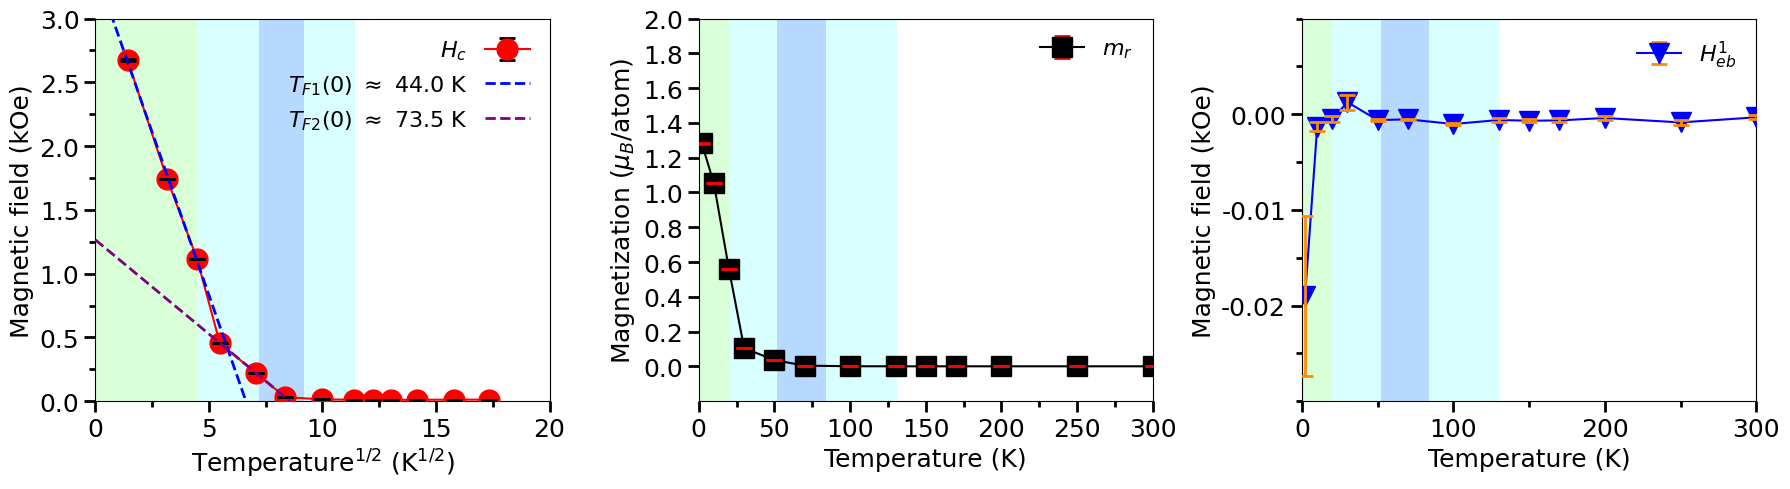

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# 1. Data Setup
# ==========================================
# (Assuming params_df is already defined in your environment)
valid_params = params_df[params_df['Status'] == 'Success'].copy()

# ==========================================
# 2. Plotting Helpers
# ==========================================
def bring_errorbars_to_front(container, z_base=10, z_err=15):
    plotline, caplines, barlinecols = container
    if plotline:
        plotline.set_zorder(z_base)
    for cap in caplines:
        cap.set_zorder(z_err)
    for bar in barlinecols:
        bar.set_zorder(z_err)

def format_axis(ax, xlabel, ylabel, xlim, ylim):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.tick_params(axis='both', which='major', length=8, width=2, labelsize=18)
    ax.tick_params(axis='both', which='minor', length=4, width=2, labelbottom=False, labelleft=False)

def add_phase_regions(ax, is_sqrt_scale=False):
    regions = [
        (0, 20, 'lime', 'Ho Conical'),
        (20, 131, 'cyan', 'Ho Helical'),
        (52, 84, 'blue', 'Er Sinusoidal')
    ]
    for start, end, color, label in regions:
        if is_sqrt_scale:
            x_start = np.sqrt(start)
            x_end = np.sqrt(end)
        else:
            x_start = start
            x_end = end
        ax.axvspan(x_start, x_end, color=color, alpha=0.15, lw=0, zorder=0)

# ==========================================
# 3. Main Visualization
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
(ax1, ax2, ax3) = axes

# Common Settings
STYLE = {'capsize': 6, 'capthick': 2, 'elinewidth': 2, 'markersize': 15}
Z_BASE = 10
LEGEND_KWARGS = {'fontsize': 16, 'loc': 'upper right', 'frameon': False}

# --- Panel 1: Hc with Fitting ---
t_sqrt = np.sqrt(valid_params['T_numeric'])
hc_kOe = valid_params['Hc'] / 1000
hc_std_kOe = valid_params['Hc_std'] / 1000

# 1. Background Regions
add_phase_regions(ax1, is_sqrt_scale=True)

# 2. Plot Data Points
container1 = ax1.errorbar(
    t_sqrt, hc_kOe, yerr=hc_std_kOe,
    fmt='o-', color='red', ecolor='black', 
    label=r'$H_c$',
    zorder=Z_BASE, **STYLE
)
bring_errorbars_to_front(container1)

# 3. Fitting Logic
x_data = t_sqrt.values
y_data = hc_kOe.values

def add_linear_fit_to_legend(ax, x_subset, y_subset, label_prefix, line_color):
    if len(x_subset) < 2: return 
    
    slope, intercept = np.polyfit(x_subset, y_subset, 1)
    x_intercept_sqrt = -intercept / slope
    t_kelvin = x_intercept_sqrt ** 2
    
    legend_label = rf'{label_prefix} $\approx$ {t_kelvin:.1f} K'
    
    x_fit_line = np.linspace(0, x_intercept_sqrt, 10)
    y_fit_line = slope * x_fit_line + intercept
    
    # zorder=20 brings the line to the front
    ax.plot(x_fit_line, y_fit_line, color=line_color, linestyle='--', linewidth=2, 
            zorder=20, label=legend_label)

# Fit 1: First 3 points (Blue)
add_linear_fit_to_legend(ax1, x_data[0:3], y_data[0:3], r'$T_{F1}(0)$', line_color='blue')

# Fit 2: Next 3 points (Purple)
add_linear_fit_to_legend(ax1, x_data[3:6], y_data[3:6], r'$T_{F2}(0)$', line_color='purple')

# 4. Legend Ordering & Alignment
handles, labels = ax1.get_legend_handles_labels()
# Sort: Hc first
hl_sorted = sorted(zip(handles, labels), key=lambda x: x[1] != r'$H_c$')
handles_sorted, labels_sorted = zip(*hl_sorted)

# markerfirst=False puts text on left, marker on right
ax1.legend(handles_sorted, labels_sorted, markerfirst=False, **LEGEND_KWARGS)

format_axis(ax1, 'Temperature$^{1/2}$ (K$^{1/2}$)', 'Magnetic field (kOe)', (0, 20), (0, 3))
ax1.set_xticks([0, 5, 10, 15, 20])
ax1.set_xticks(np.arange(0, 21, 2.5), minor=True)
ax1.set_yticks(np.arange(0, 3.1, 0.5))
ax1.set_yticks(np.arange(0, 3.01, 0.25), minor=True)

# --- Panel 2: Mr ---
add_phase_regions(ax2, is_sqrt_scale=False)
para = 672
mr_scaled = para * valid_params['Mr']
mr_std_scaled = para * valid_params['Mr_std']

container2 = ax2.errorbar(
    valid_params['T_numeric'], mr_scaled, yerr=mr_std_scaled,
    fmt='s-', color='black', ecolor='red', 
    label=r'$m_r$',
    zorder=Z_BASE, **STYLE
)
bring_errorbars_to_front(container2)
ax2.legend(**LEGEND_KWARGS)

format_axis(ax2, 'Temperature (K)', 'Magnetization ($\\mu_B$/atom)', (0, 300), (0, 2.0))
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax2.set_xticks([0, 50, 100, 150, 200, 250, 300])
ax2.set_xticks(np.arange(0, 301, 25), minor=True)
yticks_mr = np.arange(-0.2, 2.01, 0.2)
ax2.set_yticks(yticks_mr)
ax2.set_yticklabels(['' if np.isclose(v, -0.2) else f'{v:.1f}' for v in yticks_mr], fontsize=18)
for v, tick in zip(yticks_mr, ax2.yaxis.get_major_ticks()):
    if np.isclose(v, -0.2):
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)

# --- Panel 3: Heb^1 ---
add_phase_regions(ax3, is_sqrt_scale=False)
heb_kOe = valid_params['Heb'] / 1000
heb_std_kOe = valid_params['Heb_std'] / 1000

container3 = ax3.errorbar(
    valid_params['T_numeric'], heb_kOe, yerr=heb_std_kOe,
    fmt='v-', color='blue', ecolor='darkorange', 
    label=r'$H_{eb}^1$',
    zorder=Z_BASE, **STYLE
)
bring_errorbars_to_front(container3)
ax3.legend(**LEGEND_KWARGS)

format_axis(ax3, 'Temperature (K)', 'Magnetic field (kOe)', (0, 300), (-0.030, 0.010))
ax3.set_xticks([0, 100, 200, 300])
ax3.set_xticks(np.arange(0, 301, 50), minor=True)
ax3.set_yticks([-0.02, -0.01, 0.00])
ax3.set_yticklabels(['-0.02', '-0.01', '0.00'], fontsize=18)
ax3.set_yticks(np.arange(-0.03, 0.011, 0.005), minor=True)

plt.tight_layout()
plt.show()

In comparison to Figure 12, S16 from published paper plot from OriginPro

![Paper Figure S16](https://github.com/ZuomingWang/SuperconductingQuantumInterferenceDeviceProcessor/raw/main/Paper%20Figure%20S16%20from%20Origin.png)

### Model Fitting Analysis

### Quality of Fit Evaluation: Ho Helical Phase (20 - 131 K)

The impact of the **70 K data point** (associated with the Er Sinusoidal phase) is evaluated on the fitting of the Ho Helical phase. We compare two scenarios:
1.  **Exclusive Fit**: Ho Helical + Er Sinusoidal (excluding 70 K point).
2.  **Inclusive Fit**: Ho Helical + Er Sinusoidal (including 70 K point).

### Hypothesis Testing: Outlier Detection for 70 K Point

A formal test is conducted to determine whether the data point at **70 K** (within the Er Sinusoidal range) belongs to the physical trend of the **Ho Helical** phase (20-131 K).

**Null Hypothesis ($H_0$)**: The 70 K point is consistent with the Helical phase model ($H_c(T) = A e^{-BT}$).
**Alternative Hypothesis ($H_1$)**: The 70 K point is an outlier significantly deviating from this trend.

**Test Method**: The **Extra Sum-of-Squares F-Test** is employed. While typically used for nested models, it is adapted here to compare the goodness-of-fit with and without the suspect point, quantifying the penalty of inclusion against the statistical leverage.

$$ F = \frac{(SSR_{inc} - SSR_{exc}) / (N_{inc} - N_{exc})}{SSR_{exc} / (N_{exc} - p)} $$

Where $SSR$ is the sum of squared residuals, $N$ is the number of points, and $p$ is the number of model parameters (2).

In [21]:
from scipy.optimize import curve_fit
from scipy.stats import f
import numpy as np
import pandas as pd

print("--- Outlier Hypothesis Test for 70 K Point (F-Test) ---")

# 1. Data Preparation
try:
    # Ensure valid_params exists and filter for Ho Helical range
    df_helical = valid_params[
        (valid_params['T_numeric'] >= 20) & 
        (valid_params['T_numeric'] <= 131)
    ].sort_values('T_numeric').copy()
except NameError:
    # Fallback if valid_params is not defined (for standalone testing)
    data = {
        'T_numeric': [20, 30, 50, 70, 100, 130],
        'Hc': [1118.67, 458.10, 219.52, 32.07, 14.77, 12.08],
        'Hc_std': [0.29, 0.77, 0.07, 0.05, 0.11, 0.19]
    }
    df_helical = pd.DataFrame(data)

def model_exp(t, A, B):
    return A * np.exp(-B * t)

# 2. Fit Without 70K (Restricted Model)
df_exc = df_helical[df_helical['T_numeric'] != 70]
x_exc = df_exc['T_numeric'].values
y_exc = df_exc['Hc'].values

# Use unweighted fit for geometric consistency in F-test to avoid bias from tiny error bars
p0 = [3000, 0.1]
try:
    popt_exc, _ = curve_fit(model_exp, x_exc, y_exc, p0=p0, maxfev=10000)
    residuals_exc = y_exc - model_exp(x_exc, *popt_exc)
    rss_exc = np.sum(residuals_exc**2)
    n_exc = len(x_exc)
except Exception as e:
    print(f"Fit exc failed: {e}")
    rss_exc = np.inf
    n_exc = 0

# 3. Fit With 70K (Unrestricted Model)
x_inc = df_helical['T_numeric'].values
y_inc = df_helical['Hc'].values

try:
    popt_inc, _ = curve_fit(model_exp, x_inc, y_inc, p0=p0, maxfev=10000)
    residuals_inc = y_inc - model_exp(x_inc, *popt_inc)
    rss_inc = np.sum(residuals_inc**2)
    n_inc = len(x_inc)
except Exception as e:
    print(f"Fit inc failed: {e}")
    rss_inc = np.inf
    n_inc = 0

# 4. F-Test Calculation
if n_exc > 2 and n_inc > n_exc:
    p_params = 2 # A, B
    df1 = n_inc - n_exc # Difference in points
    df2 = n_exc - p_params

    numerator = (rss_inc - rss_exc) / df1
    denominator = rss_exc / df2
    F_stat = numerator / denominator
    p_value = 1 - f.cdf(F_stat, df1, df2)

    print(f"RSS (Without 70K): {rss_exc:.2f}")
    print(f"RSS (With 70K):    {rss_inc:.2f}")
    print(f"F-Statistic:       {F_stat:.4f}")
    print(f"P-Value:           {p_value:.4f}")

    alpha = 0.05
    if p_value < alpha:
        print("\nTest Result: REJECT Null Hypothesis.")
        print("Conclusion: The 70 K point is a statistically significant outlier.")
    else:
        print("\nTest Result: FAIL TO REJECT Null Hypothesis.")
        print("Conclusion: The inclusion of the 70 K point does not significantly degrade the fit quality relative to the existing scatter of the data.")
else:
    print("Insufficient data for F-Test.")


--- Outlier Hypothesis Test for 70 K Point (F-Test) ---
RSS (Without 70K): 15074.88
RSS (With 70K):    15090.41
F-Statistic:       0.0031
P-Value:           0.9592

Test Result: FAIL TO REJECT Null Hypothesis.
Conclusion: The inclusion of the 70 K point does not significantly degrade the fit quality relative to the existing scatter of the data.


## Region-Specific Hc Model Evaluation

The Coercivity ($H_c$) trends within three user-defined physical regions are evaluated:
1.  **Ho Conical** ($0 \le T \le 20$ K)
2.  **Ho Helical** ($20 \le T \le 131$ K)
3.  **Er Sinusoidal** ($52 \le T \le 84$ K)

The physical model $H_c(T) = A e^{-BT}$ is fit to each region and the **residuals** (Observed - Predicted) are analyzed to assess fit quality. Particular attention is paid to the **Er Sinusoidal** region's impact on the broader trends.

--- Robust Region Fits ---
Ho Conical: Success. A=2714.06, B=0.0443
Ho Helical: Success. A=3689.38, B=0.0588
Er Sinusoidal: Could not fit (N=1).
Paramagnetic Fit: Success. Hc=11.9 Oe


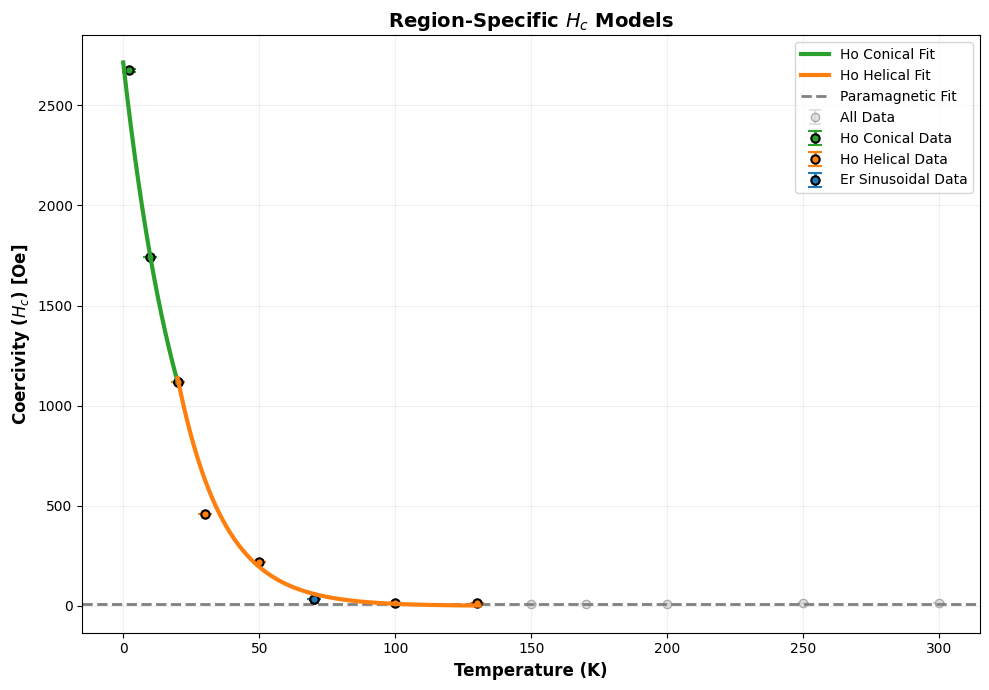

In [30]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

# --- Configuration ---
# Improved colors for better visibility and distinction
color_map = {
    'Ho Conical': '#2ca02c',      # Forest Green
    'Ho Helical': '#ff7f0e',      # Safety Orange
    'Er Sinusoidal': '#1f77b4'    # Muted Blue
}

regions = [
    (0, 20, color_map['Ho Conical'], 'Ho Conical'),
    (20, 131, color_map['Ho Helical'], 'Ho Helical'),
    (52, 84, color_map['Er Sinusoidal'], 'Er Sinusoidal')
]

def model_hc(t, A, B):
    return A * np.exp(-B * t)

# Robust Fitting Function with Smart Initialization
def robust_fit_exponential(df):
    x = df['T_numeric'].values
    y = df['Hc'].values
    y_err = df['Hc_std'].values
    
    if len(x) < 3:
        return None, None

    # 1. Guess Initial Parameters using Linearization
    mask_pos = y > 0
    if np.sum(mask_pos) >= 2:
        x_lin = x[mask_pos]
        y_lin = np.log(y[mask_pos])
        try:
            slope, intercept = np.polyfit(x_lin, y_lin, 1)
            p0_guess = [np.exp(intercept), -slope]
        except:
            p0_guess = [max(y), 0.1]
    else:
        p0_guess = [max(y), 0.1]

    try:
        # Using sigma for robust fit importance, but could optionally be unweighted if errors are unreliable
        popt, pcov = curve_fit(model_hc, x, y, sigma=y_err, absolute_sigma=True, 
                               p0=p0_guess, maxfev=20000)
        return popt, pcov
    except Exception as e:
        # Fallback to unweighted if weighted fails
        try:
            popt, pcov = curve_fit(model_hc, x, y, p0=p0_guess, maxfev=20000)
            return popt, pcov
        except:
            return None, None

# --- Fitting & Visualization ---
fig, ax = plt.subplots(figsize=(10, 7))

# Plot All Data (Background)
try:
    ax.errorbar(valid_params['T_numeric'], valid_params['Hc'], yerr=valid_params['Hc_std'], 
                fmt='o', color='lightgray', markeredgecolor='gray', ecolor='lightgray', 
                elinewidth=1.5, capsize=4, capthick=1.5,
                zorder=1, label='All Data', alpha=0.6)

    print("--- Robust Region Fits ---")

    for t_min, t_max, color, name in regions:
        # Select Data Range
        mask = (valid_params['T_numeric'] >= t_min) & (valid_params['T_numeric'] <= t_max)
        df_reg = valid_params[mask].sort_values('T_numeric')
        
        # Plot Region Data
        ax.errorbar(df_reg['T_numeric'], df_reg['Hc'], yerr=df_reg['Hc_std'], 
                    fmt='o', color=color, markeredgecolor='black', markeredgewidth=1.5,
                    ecolor=color, elinewidth=2, capsize=5, capthick=2,
                    zorder=2, label=f'{name} Data')

        # Fit
        popt, _ = robust_fit_exponential(df_reg)
        
        if popt is not None:
            # Generate Smooth Curve
            x_plot = np.linspace(t_min, t_max, 200)
            y_plot = model_hc(x_plot, *popt)
            
            ax.plot(x_plot, y_plot, '-', color=color, linewidth=3, zorder=3, 
                    label=f'{name} Fit')
            print(f"{name}: Success. A={popt[0]:.2f}, B={popt[1]:.4f}")
        else:
            print(f"{name}: Could not fit (N={len(df_reg)}).")

    # --- Paramagnetic / Background Fit (Constant) ---
    mask_high = valid_params['T_numeric'] > 131
    df_high = valid_params[mask_high]

    if len(df_high) > 0:
        hc_mean = np.mean(df_high['Hc'])
        # Plot Constant Fit
        ax.axhline(y=hc_mean, color='gray', linestyle='--', linewidth=2, zorder=2,
                   label=fr'Paramagnetic Fit')
        print(f"Paramagnetic Fit: Success. Hc={hc_mean:.1f} Oe")
    else:
        print("No data above 131K for paramagnetic fit.")


    # Styling
    ax.set_yscale('linear')
    ax.set_xlabel('Temperature (K)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Coercivity ($H_c$) [Oe]', fontsize=12, fontweight='bold')
    ax.set_title('Region-Specific $H_c$ Models', fontsize=14, fontweight='bold')
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend(fontsize=10, loc='best', frameon=True)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error in plotting: {e}")


## MR Model Evaluation

Evaluate the Remanent Magnetization ($M_r$) trends across all user-defined physical regions in a single unified view:
1.  **Ho Conical** ($0 \le T \le 20$ K)
2.  **Ho Helical** ($20 \le T \le 131$ K)
3.  **Er Sinusoidal** ($52 \le T \le 84$ K)

The fit lines for both the **Linear Model** ($M_r = aT + b$) and **Exponential Decay Model** ($M_r = A e^{-BT}$) are overlaid directly onto the data points.

The best-fitting physical model is tested for the Remanent Magnetization ($M_r$) in each region.

Model selection is based on the **Reduced Chi-Squared** ($\chi^2_\nu$) statistic. The plot below displays only the statistically superior model for each magnetic phase.

--- Region Fits for Mr ---
Ho Conical: Linear χ²ᵥ=5933.246, Exp χ²ᵥ=46220.096 → Selected Linear Fit
Ho Helical: Linear χ²ᵥ=20695027.369, Exp χ²ᵥ=3965337.942 → Selected Exp Fit
Er Sinusoidal: Not enough points → skipping fit
Paramagnetic Fit: Mr = 0.000


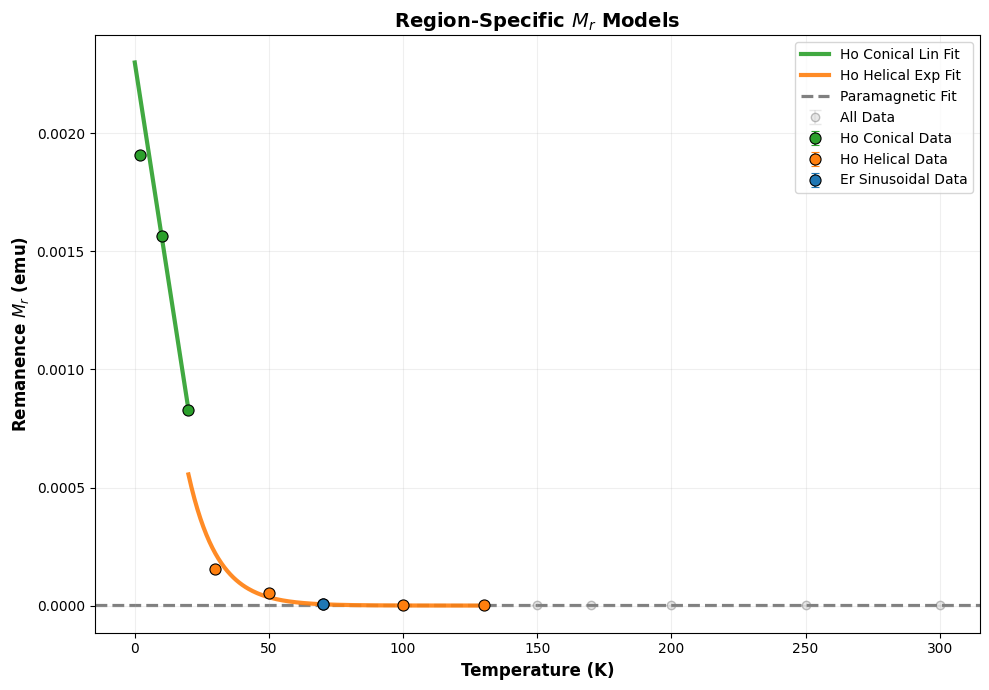

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
import numpy as np

# --- Consistent Color Map with Code1 ---
color_map = {
    'Ho Conical': '#2ca02c',      # Green (same as code1)
    'Ho Helical': '#ff7f0e',      # Orange (same as code1)
    'Er Sinusoidal': '#1f77b4'    # Blue  (same as code1)
}

regions = [
    (0, 20, color_map['Ho Conical'], 'Ho Conical'),
    (20, 131, color_map['Ho Helical'], 'Ho Helical'),
    (52, 84, color_map['Er Sinusoidal'], 'Er Sinusoidal')
]

# Models
def model_linear(t, a, b):
    return a * t + b

def model_exp(t, A, B):
    return A * np.exp(-B * t)

# --- Create Figure ---
fig, ax = plt.subplots(figsize=(10, 7))

print("--- Region Fits for Mr ---")

# ======================================================
# 1. ALL DATA BACKGROUND (like code1)
# ======================================================
try:
    ax.errorbar(valid_params['T_numeric'], valid_params['Mr'],
                yerr=(valid_params['Mr_std'] if 'Mr_std' in valid_params.columns else 0.1*valid_params['Mr']),
                fmt='o',
                color='lightgray',
                markeredgecolor='gray',
                ecolor='lightgray',
                alpha=0.5,
                markersize=6,
                elinewidth=1.2,
                capsize=4,
                zorder=1,
                label='All Data')
except:
    print("Warning: Could not plot All Data")

# ======================================================
# 2. REGION-SPECIFIC PLOTS
# ======================================================
for i, (t_min, t_max, color, name) in enumerate(regions):

    # Select data
    mask = (valid_params['T_numeric'] >= t_min) & (valid_params['T_numeric'] <= t_max)
    df_reg = valid_params[mask].sort_values('T_numeric')

    # y error
    y_err = df_reg['Mr_std'] if ('Mr_std' in df_reg.columns and df_reg['Mr_std'].sum() > 0) else 0.1 * df_reg['Mr']

    # Scatter (remove 20K overlap for Helical)
    if name == 'Ho Helical':
        df_scatter = df_reg[df_reg['T_numeric'] > 20]
    else:
        df_scatter = df_reg

    ax.errorbar(
        df_scatter['T_numeric'], df_scatter['Mr'],
        yerr=y_err[df_scatter.index],
        fmt='o', color=color, markeredgecolor='black', markeredgewidth=0.8,
        elinewidth=1.5, capsize=3, markersize=8,
        label=f'{name} Data'
    )

    n_points = len(df_reg)
    dof = n_points - 2

    if n_points < 3:
        print(f"{name}: Not enough points → skipping fit")
        continue

    try:
        # Linear fit
        popt_lin, _ = curve_fit(model_linear, df_reg['T_numeric'], df_reg['Mr'],
                                sigma=y_err, absolute_sigma=True)
        resid_lin = df_reg['Mr'] - model_linear(df_reg['T_numeric'], *popt_lin)
        red_chi_lin = np.sum((resid_lin / y_err)**2) / dof

        # Exponential fit
        try:
            p0_exp = [df_reg['Mr'].max(), 0.05]
            popt_exp, _ = curve_fit(model_exp, df_reg['T_numeric'], df_reg['Mr'],
                                    sigma=y_err, absolute_sigma=True,
                                    p0=p0_exp, maxfev=20000)
            resid_exp = df_reg['Mr'] - model_exp(df_reg['T_numeric'], *popt_exp)
            red_chi_exp = np.sum((resid_exp / y_err)**2) / dof
            fit_exp_success = True
        except:
            fit_exp_success = False
            red_chi_exp = float('inf')

        # Fit curve range
        x_fit = np.linspace(t_min, t_max, 200)

        # Select better model (legend does NOT contain chi2)
        if fit_exp_success and red_chi_exp < red_chi_lin:
            ax.plot(x_fit, model_exp(x_fit, *popt_exp),
                    color=color, linewidth=3, alpha=0.9,
                    label=f'{name} Exp Fit')
            print(f"{name}: Linear χ²ᵥ={red_chi_lin:.3f}, Exp χ²ᵥ={red_chi_exp:.3f} → Selected Exp Fit")
        else:
            ax.plot(x_fit, model_linear(x_fit, *popt_lin),
                    color=color, linestyle='-', linewidth=3, alpha=0.9,
                    label=f'{name} Lin Fit')
            print(f"{name}: Linear χ²ᵥ={red_chi_lin:.3f}, Exp χ²ᵥ={red_chi_exp:.3f} → Selected Linear Fit")

    except Exception as e:
        print(f"Fit failed for {name}: {e}")

# ======================================================
# 3. PARAMAGNETIC (HIGH-T) CONSTANT FIT — like code1
# ======================================================
mask_high = valid_params['T_numeric'] > 131
df_high = valid_params[mask_high]

if len(df_high) > 0:
    mr_mean = np.mean(df_high['Mr'])
    ax.axhline(
        y=mr_mean,
        color='gray',
        linestyle='--',
        linewidth=2.3,
        zorder=1.5,
        label='Paramagnetic Fit'
    )
    print(f"Paramagnetic Fit: Mr = {mr_mean:.3f}")
else:
    print("No data above 131 K for paramagnetic fit.")

# ======================================================
# 4. Styling (match Code1)
# ======================================================
ax.set_xlabel('Temperature (K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Remanence $M_r$ (emu)', fontsize=12, fontweight='bold')
ax.set_title('Region-Specific $M_r$ Models', fontsize=14, fontweight='bold')

ax.grid(True, which="both", linestyle='-', alpha=0.2)
ax.legend(fontsize=10, loc='best', frameon=True)

plt.tight_layout()
plt.show()


# DISCUSSION


**Class assignments** related to the building of this section include:


*   Approaches to Background Fitting (Lecture)
*   How does subtracting the magnetic contribution of a substrate from an M-H curve contribute to error in the data?
*   How does this effect the error in extracted physical properties like saturated moment?





## Understanding Exceptionally Large Error Bars at T = 2K

**Error Propagation Methodology:**

Remanence and exchange bias are derived quantities calculated by interpolating to specific field values (H = 0 for Mr, zero-crossing fields for Heb) and averaging between loop branches. Uncertainties propagate through these operations via standard error propagation formulas:

- **For Mr = (Mr⁺ + Mr⁻)/2:** σ_Mr = √[(σ_Mr⁺)² + (σ_Mr⁻)²] / 2
- **For Heb = (H⁺ + H⁻)/2:** σ_Heb = √[(σ_H⁺)² + (σ_H⁻)²] / 2

Each interpolation uncertainty is calculated from the SQUID-reported `M. Std. Err.` values of nearby data points using calculus-based error propagation through the interpolation formulas. Zero-crossing detection propagates errors by computing derivatives ∂H/∂M₁ and ∂H/∂M₂ for the linear interpolation formula H = H₁ - M₁(H₂-H₁)/(M₂-M₁), then applying quadrature addition: σ²_H = (∂H/∂M₁ · σ_M₁)² + (∂H/∂M₂ · σ_M₂)².
At T = 2K, individual points near H = 0 have errors ~7.4×10⁻⁶ emu. Propagating through Mr calculation: σ_Mr ≈ √[2×(7.4×10⁻⁶)²]/2 ≈ 5.2×10⁻⁶ emu, matching the reported 5.4×10⁻⁶ emu

**Why Errors Are So Large at 2K:**

**1. Measurement Noise is 18.5× Higher at 2K Than at 10K**

| Temperature | Mean M. Std. Err. | Ratio to 2K |
|-------------|-------------------|-------------|
| 2K | 1.07×10⁻⁵ emu | 1.0× (baseline) |
| 10K | 5.79×10⁻⁷ emu | 0.05×  |
| 50K | 1.51×10⁻⁷ emu | 0.01×  |

Physical origins specific to Ho/Er multilayers:
Magnetic domain fluctuations in the conical phase create time-varying noise.
Critical fluctuations near magnetic ordering temperature (T ≈ 2K approaches the conical phase transition around 20K where susceptibility diverges and fluctuation-dissipation theorem predicts ⟨δM²⟩ ∝ χ).
Interfacial spin disorder undergoes slow relaxation with time scales comparable to measurement duration.
SQUID superconducting flux noise from vortex motion at very low temperatures.

**2. The Physical Signals Are Extremely Weak**

This tiny remanence is a real effect due to the conical magnetic structure: when H = 0, the helical spin pattern relaxes toward zero net magnetization. Only interfacial pinning preserves a tiny remnant moment.

**3. Error Amplification Through Subtraction and Interpolation**

Measurement noise scales with typical moment size (~1.9×10⁻³ emu), but remanence is 450× smaller due to physics. When subtracting two noisy measurements to get a tiny difference, errors add in quadrature while signals can cancel, amplifying relative uncertainty.